In [2]:
import pandas as pd
import numpy as np

from trainer import trainer_tcn
from outils.gridsearch import grid_search

In [3]:
# LOAD DATA
df = pd.read_csv("WADI_clean.csv")

target = "3_LT_001_PV"

df = df.ffill()

df = df.drop(columns=["Datetime"])

# SPLIT (time series)
split_1 = int(len(df) * 0.7)
split_2 = int(len(df) * 0.85)

train_df = df.iloc[:split_1]
val_df = df.iloc[split_1:split_2]
test_df = df.iloc[split_2:]


print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test :", test_df.shape)

Train: (142881, 121)
Validation: (30617, 121)
Test : (30618, 121)


In [4]:
p_grid = {
    "seq_len": [20, 30],
    "horizon": [1, 10],
    "batch_size": [32, 64],
    "epochs": [20],
    "lr": [1e-3],
    "strategy": ["direct"]
}

GridSearch sur 8 combinaisons
n_jobs = 1


 Meilleurs paramètres :
seq_len              30
horizon              10
batch_size           32
epochs               20
lr                0.001
strategy         direct
val_loss      23.249559
val_mae        3.940903
Name: 6, dtype: object


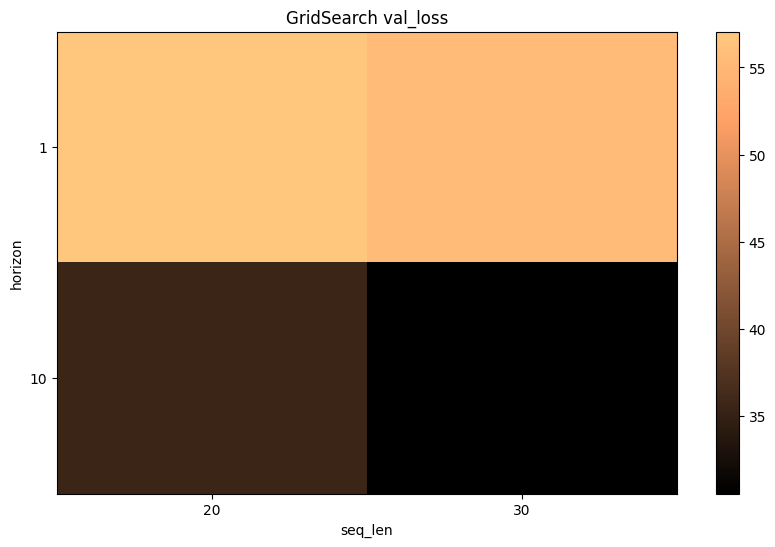

   seq_len  horizon  batch_size  epochs     lr strategy   val_loss   val_mae
0       20        1          32      20  0.001   direct  30.817343  4.420373
1       20        1          64      20  0.001   direct  83.284523  8.288078
2       20       10          32      20  0.001   direct  35.154480  4.770881
3       20       10          64      20  0.001   direct  35.927402  4.885483
4       30        1          32      20  0.001   direct  60.657223  6.641120
5       30        1          64      20  0.001   direct  50.266163  6.258906
6       30       10          32      20  0.001   direct  23.249559  3.940903
7       30       10          64      20  0.001   direct  37.878613  4.935842


In [6]:
df_results = grid_search(
    trainer=trainer_tcn,
    train_df=train_df,
    val_df=val_df,
    p_grid=p_grid,
    n_jobs=1,
    target_col = target
)

print(df_results)

In [7]:
p_grid_recursive = {
    "seq_len": [20, 30],
    "horizon": [1],
    "batch_size": [32, 64],
    "epochs": [20],
    "lr": [1e-3],
    "strategy": ["recursive"]
}

GridSearch sur 4 combinaisons
n_jobs = 1

 Meilleurs paramètres :
seq_len              30
horizon               1
batch_size           64
epochs               20
lr                0.001
strategy      recursive
val_loss      11.028559
val_mae        2.810772
Name: 3, dtype: object


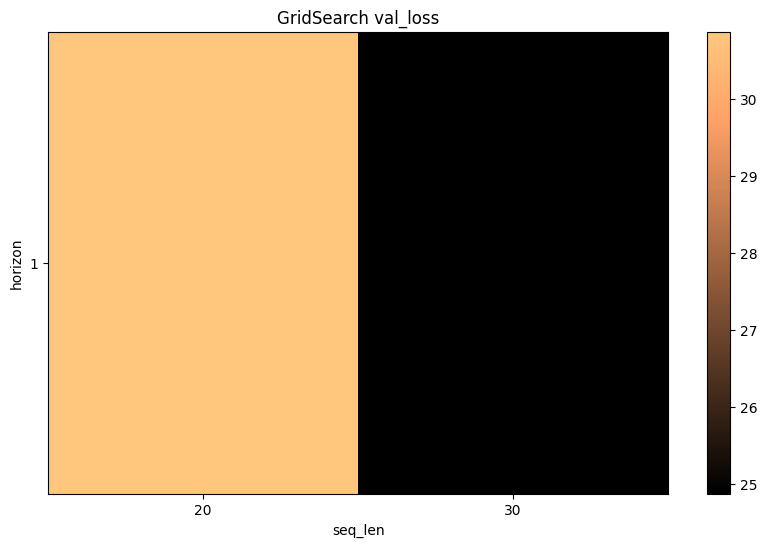

   seq_len  horizon  batch_size  epochs     lr   strategy   val_loss   val_mae
0       20        1          32      20  0.001  recursive  32.518944  4.652625
1       20        1          64      20  0.001  recursive  29.219242  4.423594
2       30        1          32      20  0.001  recursive  38.725582  5.296685
3       30        1          64      20  0.001  recursive  11.028559  2.810772


In [8]:
df_results = grid_search(
    trainer=trainer_tcn,
    train_df=train_df,
    val_df=val_df,
    p_grid=p_grid_recursive,
    n_jobs=1,
    target_col = target
)

print(df_results)